# Customer Segmentation Study #
Methodology: PCA + KMeans + Silhouette + Stability Validation

## 1. Imports ##
We imported pandas and numpy for data handling, matplotlib and seaborn for visualization, and sklearn for preprocessing, PCA, clustering, and evaluation. Warnings were suppressed to avoid unnecessary outputs, and ggplot style was set for consistent visuals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

## 2. Load Data 
### Dataset Description


This project uses four datasets that capture different levels of customer purchasing behavior in a grocery retail environment. The data includes **basket transactions, item purchases, category spending , and customer information**.

---

### 1. Basket Dataset
**File:** `baskets_sample.csv`

This dataset contains information about each **shopping basket transaction** made by a customer.

| Column Name | Description |
|-------------|-------------|
| `customer_number` | Unique identifier for each customer |
| `purchase_time` | Timestamp indicating when the basket transaction occurred |
| `basket_quantity` | Total number of items purchased in the basket |
| `basket_spend` | Total amount spent in the basket transaction |
| `basket_categories` | Number of distinct product categories included in the basket |

---

## 2. Line Item Dataset
**File:** `lineitems_sample.csv`

This dataset provides **product-level transaction data**, showing each item purchased within a basket.

| Column Name | Description |
|-------------|-------------|
| `customer_number` | Unique identifier for each customer |
| `purchase_time` | Timestamp of the transaction |
| `product_id` | Unique identifier for the purchased product |
| `category` | Product category to which the item belongs |
| `quantity` | Number of units purchased for the product |
| `spend` | Amount spent on the product |

---

### 3. Category Spending Dataset
**File:** `category_spends_sample_3.csv`

This dataset summarizes **customer spending across different product categories**.

| Column Name | Description |
|-------------|-------------|
| `customer_number` | Unique identifier for each customer |
| `BAKERY` | Total spending on bakery products |
| `CASHPOINT` | Spending related to cashpoint services |
| `CONFECTIONARY` | Spending on confectionery items such as sweets and chocolates |
| `DAIRY` | Spending on dairy products |
| `DELI` | Spending on delicatessen items |
| `DISCOUNT_BAKERY` | Spending on discounted bakery items |
| `DRINKS` | Spending on beverages |
| `FROZEN` | Spending on frozen food products |
| `FRUIT_VEG` | Spending on fruits and vegetables |
| `GROCERY_FOOD` | Spending on packaged grocery food products |
| `GROCERY_HEALTH_PETS` | Spending on health-related products and pet items |
| `LOTTERY` | Spending on lottery tickets |
| `MEAT` | Spending on meat products |
| `NEWSPAPERS_MAGAZINES` | Spending on newspapers and magazines |
| `PRACTICAL_ITEMS` | Spending on household practical items |
| `PREPARED_MEALS` | Spending on ready-to-eat meals |
| `SEASONAL_GIFTING` | Spending on seasonal or gift-related items |
| `SOFT_DRINKS` | Spending on soft drinks |
| `TOBACCO` | Spending on tobacco products |
| `WORLD_FOODS` | Spending on international food products |

---

### 4. Customer Dataset
**File:** `customers_sample_3.csv`

This dataset contains **aggregated purchasing behavior for each customer**.

| Column Name | Description |
|-------------|-------------|
| `customer_number` | Unique identifier for each customer |
| `baskets` | Total number of shopping baskets purchased by the customer |
| `total_quantity` | Total number of items purchased across all baskets |
| `average_quantity` | Average number of items purchased per basket |
| `total_spend` | Total spending by the customer |
| `average_spend` | Average spending per basket |

---

In [2]:
customers = pd.read_csv("customers_sample_3.csv")
categories = pd.read_csv("category_spends_sample_3.csv")
baskets = pd.read_csv("baskets_sample.csv")
items = pd.read_csv("lineitems_sample.csv")

print("CSV files Loaded")

CSV files Loaded


Checking File integrities

In [3]:
customers.isna().sum()

customer_number     0
baskets             0
total_quantity      0
average_quantity    0
total_spend         0
average_spend       0
dtype: int64

In [4]:
customers.describe()

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,8095.724333,65.182333,583.722000,11.273507,769.412937,14.801280
std,4686.259488,47.464717,405.006359,8.538024,552.769022,11.161387
min,14.000000,1.000000,6.000000,1.200000,7.280000,1.460000
25%,4044.750000,32.000000,307.750000,6.117500,406.120000,8.037500
50%,8218.500000,53.000000,495.000000,8.730000,627.170000,11.770000
75%,12115.500000,86.000000,744.250000,13.390000,957.675000,17.440000
max,16316.000000,374.000000,4949.000000,90.750000,6588.650000,152.620000


In [5]:
customers.head()

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend
0,14,56,531,9.48,675.72,12.07
1,45,33,655,19.85,585.73,17.75
2,52,59,294,4.98,222.18,3.77
3,61,37,499,13.49,547.87,14.81
4,63,48,281,5.85,293.34,6.11


In [6]:
categories.isna().sum()


customer_number         0
BAKERY                  0
CASHPOINT               0
CONFECTIONARY           0
DAIRY                   0
DELI                    0
DISCOUNT_BAKERY         0
DRINKS                  0
FROZEN                  0
FRUIT_VEG               0
GROCERY_FOOD            0
GROCERY_HEALTH_PETS     0
LOTTERY                 0
MEAT                    0
NEWSPAPERS_MAGAZINES    0
PRACTICAL_ITEMS         0
PREPARED_MEALS          0
SEASONAL_GIFTING        0
SOFT_DRINKS             0
TOBACCO                 0
WORLD_FOODS             0
dtype: int64

In [7]:
categories.describe()

,customer_number,BAKERY,CASHPOINT,CONFECTIONARY,DAIRY,DELI,DISCOUNT_BAKERY,DRINKS,FROZEN,FRUIT_VEG,...,GROCERY_HEALTH_PETS,LOTTERY,MEAT,NEWSPAPERS_MAGAZINES,PRACTICAL_ITEMS,PREPARED_MEALS,SEASONAL_GIFTING,SOFT_DRINKS,TOBACCO,WORLD_FOODS
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,8095.724333,19.892510,23.563743,79.581263,94.408837,7.037300,1.607183,50.186043,23.487570,80.472787,...,39.122713,7.409633,35.772383,7.841553,1.694130,20.544407,6.352777,15.290923,62.580747,5.822933
std,4686.259488,28.355582,78.190956,112.109163,97.039937,13.941201,14.095479,110.335636,35.004389,108.311955,...,54.381349,29.478477,54.442189,13.392407,5.837355,32.192419,17.251581,30.603984,248.505264,16.890666
min,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4044.750000,6.590000,0.000000,25.910000,38.197500,0.000000,0.000000,0.000000,4.880000,24.410000,...,9.820000,0.000000,5.987500,0.445000,0.000000,3.700000,0.000000,1.477500,0.000000,0.000000
50%,8218.500000,13.610000,0.000000,53.715000,70.355000,1.660000,0.000000,9.345000,13.690000,55.585000,...,23.265000,0.000000,18.730000,3.470000,0.000000,11.805000,0.890000,5.970000,0.000000,1.875000
75%,12115.500000,24.345000,10.000000,98.160000,120.445000,7.982500,0.000000,49.382500,29.637500,104.185000,...,48.045000,2.000000,44.440000,9.967500,1.520000,25.205000,5.372500,16.977500,34.905000,6.350000
max,16316.000000,473.440000,1924.680000,2671.340000,2390.030000,143.780000,488.290000,2252.400000,675.110000,3800.060000,...,1121.320000,637.000000,882.580000,258.990000,195.560000,691.350000,347.720000,630.550000,6255.170000,609.680000


In [8]:
categories.head()

,customer_number,BAKERY,CASHPOINT,CONFECTIONARY,DAIRY,DELI,DISCOUNT_BAKERY,DRINKS,FROZEN,FRUIT_VEG,...,GROCERY_HEALTH_PETS,LOTTERY,MEAT,NEWSPAPERS_MAGAZINES,PRACTICAL_ITEMS,PREPARED_MEALS,SEASONAL_GIFTING,SOFT_DRINKS,TOBACCO,WORLD_FOODS
0,14,7.40,0.0,25.53,236.09,0.00,1.25,189.8,20.57,14.48,...,25.40,0.0,88.46,6.40,0.00,17.29,7.61,6.03,0.0,33.66
1,45,9.45,0.0,126.32,181.58,0.00,0.00,0.0,4.51,30.21,...,13.76,0.0,59.39,7.62,0.00,37.18,0.00,30.17,0.0,4.37
2,52,1.04,0.0,3.29,5.19,26.24,0.00,0.0,1.78,56.27,...,13.63,0.0,9.96,1.99,0.00,0.00,22.10,3.17,0.0,54.90
3,61,14.08,0.0,69.29,61.15,3.81,0.00,13.0,21.96,83.74,...,19.63,0.0,53.52,1.60,1.52,6.88,9.12,10.93,0.0,1.19
4,63,12.12,0.0,75.66,43.60,11.67,0.00,0.0,3.88,22.01,...,7.47,4.0,2.49,0.45,0.00,0.00,0.00,1.19,0.0,5.79


In [9]:
baskets.isna().sum()

customer_number      0
purchase_time        0
basket_quantity      0
basket_spend         0
basket_categories    0
dtype: int64

In [10]:
baskets.describe()

,customer_number,basket_quantity,basket_categories
count,195547.000000,195547.000000,195547.000000
mean,7896.492899,8.955218,4.231990
std,4408.251411,9.510890,2.478016
min,14.000000,-11.000000,1.000000
25%,4323.000000,3.000000,2.000000
50%,7944.000000,6.000000,4.000000
75%,11324.000000,11.000000,6.000000
max,16316.000000,190.000000,16.000000


In [11]:
baskets.head()

,customer_number,purchase_time,basket_quantity,basket_spend,basket_categories
0,11911,2007-03-01 07:06:00,7,£3.09,3
1,4047,2007-03-01 07:13:00,9,£7.99,5
2,3571,2007-03-01 07:27:00,9,£37.06,6
3,4079,2007-03-01 07:34:00,11,£11.91,5
4,6063,2007-03-01 07:36:00,3,£1.45,1


In [12]:
items.isna().sum()

customer_number    0
purchase_time      0
product_id         0
category           0
quantity           0
spend              0
dtype: int64

In [13]:
items.describe()

,customer_number,product_id,quantity
count,1.461315e+06,1.461315e+06,1.461315e+06
mean,7.748199e+03,3.940964e+05,1.198349e+00
std,4.405076e+03,2.989743e+05,5.990824e-01
min,1.400000e+01,2.200000e+01,-1.300000e+01
25%,4.028000e+03,6.027800e+04,1.000000e+00
50%,7.823000e+03,5.612280e+05,1.000000e+00
75%,1.121100e+04,6.953890e+05,1.000000e+00
max,1.631600e+04,7.450580e+05,1.000000e+02


In [14]:
items.head()

,customer_number,purchase_time,product_id,category,quantity,spend
0,14577,2007-03-10 11:58:00,722653,GROCERY_FOOD,1,£1.39
1,7210,2007-03-22 10:53:00,696136,GROCERY_HEALTH_PETS,1,£4.25
2,3145,2007-03-26 11:17:00,139543,GROCERY_HEALTH_PETS,1,£0.50
3,2649,2007-03-12 16:05:00,34890,BAKERY,1,£0.57
4,859,2007-03-10 09:53:00,613984,BAKERY,1,£1.59


In [3]:
# Upon inspections there are columns that are loaded with £ symbol, so we will remove them and cast those as float type
# It's in baskets (basket_spend) & items (spend)

for col in ['basket_spend']:
    if baskets[col].dtype == object:
        baskets[col] = baskets[col].str.replace('£','').astype(float)

for col in ['spend']:
    if items[col].dtype == object:
        items[col] = items[col].str.replace('£','').astype(float)

In [16]:
(customers < 0).sum()

customer_number     0
baskets             0
total_quantity      0
average_quantity    0
total_spend         0
average_spend       0
dtype: int64

In [17]:
(categories < 0).sum()

customer_number         0
BAKERY                  0
CASHPOINT               0
CONFECTIONARY           0
DAIRY                   0
DELI                    0
DISCOUNT_BAKERY         0
DRINKS                  0
FROZEN                  0
FRUIT_VEG               0
GROCERY_FOOD            0
GROCERY_HEALTH_PETS     0
LOTTERY                 0
MEAT                    0
NEWSPAPERS_MAGAZINES    0
PRACTICAL_ITEMS         0
PREPARED_MEALS          0
SEASONAL_GIFTING        0
SOFT_DRINKS             0
TOBACCO                 0
WORLD_FOODS             0
dtype: int64

In [18]:
baskets_temp= baskets.select_dtypes(include=['number'])
(baskets_temp < 0).sum()

customer_number        0
basket_quantity       19
basket_spend         160
basket_categories      0
dtype: int64

In [19]:
returns_baskets = baskets[(baskets['basket_spend'] < 0) | (baskets['basket_quantity'] < 0)]
clean_baskets = baskets[(baskets['basket_spend'] >= 0) & (baskets['basket_quantity'] >= 0)]

In [20]:
items_temp= items.select_dtypes(include=['number'])
(items_temp < 0).sum()

customer_number      0
product_id           0
quantity           864
spend              864
dtype: int64

In [21]:
returns_items = items[(items['spend'] < 0) | (items['quantity'] < 0)]
clean_items = items[(items['spend'] >= 0) & (items['quantity'] >= 0)]

<h2>3. Merge Customer Data</h2>

Merging ensures that segmentation is based on all relevant aspects of behavior, improving the quality and interpretability of clusters. We are going to merge core customer data with category summaries using customer_number as the key.

In [22]:
# Merge customer + category spend
data = customers.merge(categories, on="customer_number", how="left")

data.head()

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend,BAKERY,CASHPOINT,CONFECTIONARY,DAIRY,...,GROCERY_HEALTH_PETS,LOTTERY,MEAT,NEWSPAPERS_MAGAZINES,PRACTICAL_ITEMS,PREPARED_MEALS,SEASONAL_GIFTING,SOFT_DRINKS,TOBACCO,WORLD_FOODS
0,14,56,531,9.48,675.72,12.07,7.40,0.0,25.53,236.09,...,25.40,0.0,88.46,6.40,0.00,17.29,7.61,6.03,0.0,33.66
1,45,33,655,19.85,585.73,17.75,9.45,0.0,126.32,181.58,...,13.76,0.0,59.39,7.62,0.00,37.18,0.00,30.17,0.0,4.37
2,52,59,294,4.98,222.18,3.77,1.04,0.0,3.29,5.19,...,13.63,0.0,9.96,1.99,0.00,0.00,22.10,3.17,0.0,54.90
3,61,37,499,13.49,547.87,14.81,14.08,0.0,69.29,61.15,...,19.63,0.0,53.52,1.60,1.52,6.88,9.12,10.93,0.0,1.19
4,63,48,281,5.85,293.34,6.11,12.12,0.0,75.66,43.60,...,7.47,4.0,2.49,0.45,0.00,0.00,0.00,1.19,0.0,5.79


In [23]:
# Removing customers with only 1 basket (Means only 1 time purchase, there's no pattern to track)
data = data[data['baskets'] >= 2]

In [24]:
# We are left with 2997 customers
data.describe()

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend,BAKERY,CASHPOINT,CONFECTIONARY,DAIRY,...,GROCERY_HEALTH_PETS,LOTTERY,MEAT,NEWSPAPERS_MAGAZINES,PRACTICAL_ITEMS,PREPARED_MEALS,SEASONAL_GIFTING,SOFT_DRINKS,TOBACCO,WORLD_FOODS
count,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,...,2997.000000,2997.00000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000,2997.000000
mean,8094.512179,65.246580,584.265599,11.244084,770.120948,14.753924,19.908879,23.587331,79.650694,94.496273,...,39.152139,7.41705,35.804077,7.848071,1.695826,20.560914,6.356587,15.302516,62.643390,5.828432
std,4684.519263,47.444982,404.844042,8.485390,552.592075,11.061328,28.364919,78.226537,112.143580,97.049054,...,54.400168,29.49230,54.459904,13.397392,5.840030,32.204128,17.259420,30.616916,248.621757,16.898219
min,14.000000,2.000000,6.000000,1.200000,7.280000,1.460000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4045.000000,32.000000,308.000000,6.110000,406.720000,8.030000,6.600000,0.000000,25.990000,38.300000,...,9.830000,0.00000,6.000000,0.450000,0.000000,3.700000,0.000000,1.480000,0.000000,0.000000
50%,8217.000000,53.000000,495.000000,8.730000,627.460000,11.760000,13.610000,0.000000,53.760000,70.430000,...,23.320000,0.00000,18.780000,3.480000,0.000000,11.820000,0.890000,5.970000,0.000000,1.880000
75%,12110.000000,86.000000,745.000000,13.380000,958.350000,17.430000,24.360000,10.000000,98.250000,120.520000,...,48.060000,2.00000,44.470000,9.990000,1.520000,25.220000,5.370000,17.000000,34.980000,6.350000
max,16316.000000,374.000000,4949.000000,90.750000,6588.650000,152.620000,473.440000,1924.680000,2671.340000,2390.030000,...,1121.320000,637.00000,882.580000,258.990000,195.560000,691.350000,347.720000,630.550000,6255.170000,609.680000


<h2>4. Feature Engineering</h2>

<h3>CATEGORY PREFERENCES</h3>
Dividing categories into 4 thematic groups:

**1. Essentials**

These are everyday necessities that customers regularly buy.

* DAIRY
* FRUIT_VEG
* GROCERY_FOOD
* MEAT
* FROZEN
* BAKERY
* DISCOUNT_BAKERY

**2. Indulgence**

Items bought for pleasure, treat, or occasional enjoyment.

* CONFECTIONARY
* SOFT_DRINKS
* DRINKS (Assuming alcoholic or premium drinks are included)
* SEASONAL_GIFTING

**3. Convenience**

Products purchased for ease, ready-to-eat, or quick use.

* DELI 
* PREPARED_MEALS
* CASHPOINT (referring to self-service payment or vending)
* PRACTICAL_ITEMS

**4. Lifestyle**

Categories that reflect personal habits, hobbies, or premium lifestyle choices.

* WORLD_FOODS
* GROCERY_HEALTH_PETS
* LOTTERY
* TOBACCO
* NEWSPAPERS_MAGAZINES

Grouping product categories allows us to capture customer preferences at a higher abstraction level. Ratios indicate relative spending priorities. Ratios normalize for total spend, making clusters independent of absolute spending and focusing on behavioral tendencies.

In [25]:
essentials_cols = ['BAKERY','DISCOUNT_BAKERY','DAIRY','FRUIT_VEG','GROCERY_FOOD','MEAT','FROZEN']
indulgence_cols = ['CONFECTIONARY','SOFT_DRINKS','DRINKS','SEASONAL_GIFTING']
convenience_cols = ['DELI','PREPARED_MEALS','PRACTICAL_ITEMS','CASHPOINT']
lifestyle_cols = ['WORLD_FOODS','GROCERY_HEALTH_PETS','LOTTERY','TOBACCO','NEWSPAPERS_MAGAZINES']

data["essentials_spend"] = data[essentials_cols].sum(axis=1)
data["indulgence_spend"] = data[indulgence_cols].sum(axis=1)
data["convenience_spend"] = data[convenience_cols].sum(axis=1)
data["lifestyle_spend"] = data[lifestyle_cols].sum(axis=1)

# Convert to proportions
data["essentials_ratio"] = data["essentials_spend"] / data["total_spend"]
data["indulgence_ratio"] = data["indulgence_spend"] / data["total_spend"]
data["convenience_ratio"] = data["convenience_spend"] / data["total_spend"]
data["lifestyle_ratio"] = data["lifestyle_spend"] / data["total_spend"]

<h3>CUSTOMER ENGAGEMENT & VALUE</h3>

**1. Recency**

Days since last purchase.

In [26]:
clean_baskets["purchase_time"] = pd.to_datetime(clean_baskets["purchase_time"])

analysis_date = clean_baskets["purchase_time"].max()

recency = (
    clean_baskets.groupby("customer_number")["purchase_time"]
    .max()
    .reset_index()
)

recency["recency_days"] = (
    analysis_date - recency["purchase_time"]
).dt.days

recency = recency[["customer_number","recency_days"]]

**2. Visit Regularity**

* Low std → routine shopper
* High std → irregular / mission shopper

In [27]:
clean_baskets = clean_baskets.sort_values(["customer_number","purchase_time"])

clean_baskets["prev_visit"] = clean_baskets.groupby("customer_number")["purchase_time"].shift(1)

clean_baskets["days_between"] = (
    clean_baskets["purchase_time"] - clean_baskets["prev_visit"]
).dt.days

visit_regularity = (
    clean_baskets.groupby("customer_number")["days_between"]
    .std()
    .reset_index()
)

visit_regularity.rename(columns={"days_between":"visit_gap_std"}, inplace=True)

**Merge Time Feature**

Temporal patterns describe lifecycle stage (recent vs. inactive) and predictability (routine vs. mission shopper)

In [28]:
time_features = recency.merge(visit_regularity, on="customer_number")

data = data.merge(time_features, on="customer_number", how="left")

## BASKET STYLE

Compute basket-level metrics per customer: mean and standard deviation of basket spend, basket quantity, and basket category diversity.

Basket characteristics add granularity to understanding customer behavior beyond aggregate spend. These features help differentiate clusters that might otherwise appear similar in total spend but differ in purchase patterns and complexity.

In [29]:
# Ensure 'basket_categories' is string and fill NaNs
clean_baskets['basket_categories'] = clean_baskets['basket_categories'].astype(str).fillna('')

# Now aggregate basket stats safely
basket_stats = clean_baskets.groupby('customer_number').agg(
    basket_quantity_mean=('basket_quantity', 'mean'),
    basket_quantity_std=('basket_quantity', 'std'),
    basket_spend_mean=('basket_spend', 'mean'),
    basket_spend_std=('basket_spend', 'std'),
    basket_category_diversity=('basket_categories', lambda x: x.str.split(',').apply(len).mean())
).reset_index()

In [30]:
data = data.merge(basket_stats, on="customer_number", how="left")

In [31]:
data.isna().sum()

customer_number              0
baskets                      0
total_quantity               0
average_quantity             0
total_spend                  0
average_spend                0
BAKERY                       0
CASHPOINT                    0
CONFECTIONARY                0
DAIRY                        0
DELI                         0
DISCOUNT_BAKERY              0
DRINKS                       0
FROZEN                       0
FRUIT_VEG                    0
GROCERY_FOOD                 0
GROCERY_HEALTH_PETS          0
LOTTERY                      0
MEAT                         0
NEWSPAPERS_MAGAZINES         0
PRACTICAL_ITEMS              0
PREPARED_MEALS               0
SEASONAL_GIFTING             0
SOFT_DRINKS                  0
TOBACCO                      0
WORLD_FOODS                  0
essentials_spend             0
indulgence_spend             0
convenience_spend            0
lifestyle_spend              0
essentials_ratio             0
indulgence_ratio             0
convenie

In [32]:
# After checking there is null values in visit_gap_std, so we will put 0
# This is might be because of the customer has multiple baskets on the same timestamp (day)
data['visit_gap_std'] = data['visit_gap_std'].fillna(0)

In [33]:
data.columns.tolist()

['customer_number',
 'baskets',
 'total_quantity',
 'average_quantity',
 'total_spend',
 'average_spend',
 'BAKERY',
 'CASHPOINT',
 'CONFECTIONARY',
 'DAIRY',
 'DELI',
 'DISCOUNT_BAKERY',
 'DRINKS',
 'FROZEN',
 'FRUIT_VEG',
 'GROCERY_FOOD',
 'GROCERY_HEALTH_PETS',
 'LOTTERY',
 'MEAT',
 'NEWSPAPERS_MAGAZINES',
 'PRACTICAL_ITEMS',
 'PREPARED_MEALS',
 'SEASONAL_GIFTING',
 'SOFT_DRINKS',
 'TOBACCO',
 'WORLD_FOODS',
 'essentials_spend',
 'indulgence_spend',
 'convenience_spend',
 'lifestyle_spend',
 'essentials_ratio',
 'indulgence_ratio',
 'convenience_ratio',
 'lifestyle_ratio',
 'recency_days',
 'visit_gap_std',
 'basket_quantity_mean',
 'basket_quantity_std',
 'basket_spend_mean',
 'basket_spend_std',
 'basket_category_diversity']

<h2>5. Select Final Feature Set</h2>

Selected 9 features covering customer behavior, categories ratios, basket behavior

In [34]:
features = [
    "recency_days",
    "baskets",
    "total_spend",

    "basket_quantity_mean",
    "basket_spend_mean",

    "essentials_ratio",
    "indulgence_ratio",
    "convenience_ratio",
    "lifestyle_ratio"
]

data[features].skew().sort_values(ascending=False)

lifestyle_ratio         6.503933
convenience_ratio       4.640539
recency_days            4.521224
indulgence_ratio        4.416579
basket_spend_mean       3.237880
basket_quantity_mean    2.926796
total_spend             2.227921
baskets                 1.744868
essentials_ratio        0.849965
dtype: float64

In [35]:
data_ori = data.copy()

In [36]:
# Features to log-transform
log_features = [
    "recency_days",
    "basket_spend_mean",
    "basket_quantity_mean",
    "total_spend",
    "baskets"
]

# Apply log1p and replace original columns
for feat in log_features:
    if feat in data.columns:
        # Ensure all values are non-negative
        if (data[feat] >= 0).all():
            data[feat] = np.log1p(data[feat])
            print(f"{feat} log-transformed. New skew:", data[feat].skew())
        else:
            print(f"{feat} has negative values, cannot log-transform")

recency_days log-transformed. New skew: 1.0470927848567704
basket_spend_mean log-transformed. New skew: 0.48499495162390366
basket_quantity_mean log-transformed. New skew: 0.5689119903127967
total_spend log-transformed. New skew: -0.44657366460862585
baskets log-transformed. New skew: -0.39422742158534674


In [37]:
data[features].skew().sort_values(ascending=False)

lifestyle_ratio         6.503933
convenience_ratio       4.640539
indulgence_ratio        4.416579
recency_days            1.047093
essentials_ratio        0.849965
basket_quantity_mean    0.568912
basket_spend_mean       0.484995
baskets                -0.394227
total_spend            -0.446574
dtype: float64

In [38]:
X = data[features].fillna(0)

<h2>6. Scaling</h2>

All features are scaled to zero mean and unit variance to ensure that no single feature dominates the clustering due to scale differences. Essential for distance-based methods like KMeans and PCA.

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<h2>7. PCA</h2>

PCA reduces dimensionality, removes noise, and captures the most important variation across customers.

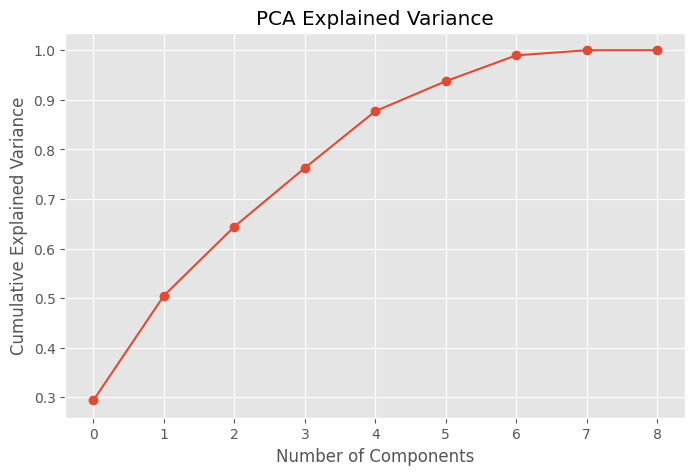

In [40]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [41]:
# Retaining 80% of components for better silhouette and segmentation (Usually 80-90% is the ideal variants to keep)
pca = PCA(n_components=0.8)
X_pca = pca.fit_transform(X_scaled)

print("Number of components retained:", pca.n_components_)

Number of components retained: 5


<h2>8. Determine Optimal k</h2>
Elbow + Silhouette

Applied KMeans for k=4 to 10. Evaluated using Elbow method (inertia) and Silhouette scores.

* Inertia measures compactness of clusters (lower is better).

* Silhouette measures separation (closer to 1 is better). 


In this case, Silhouette score of 0.2 - 0.35 is normal and 0.35 above is almost perfect as customers behavior isn't perfect.

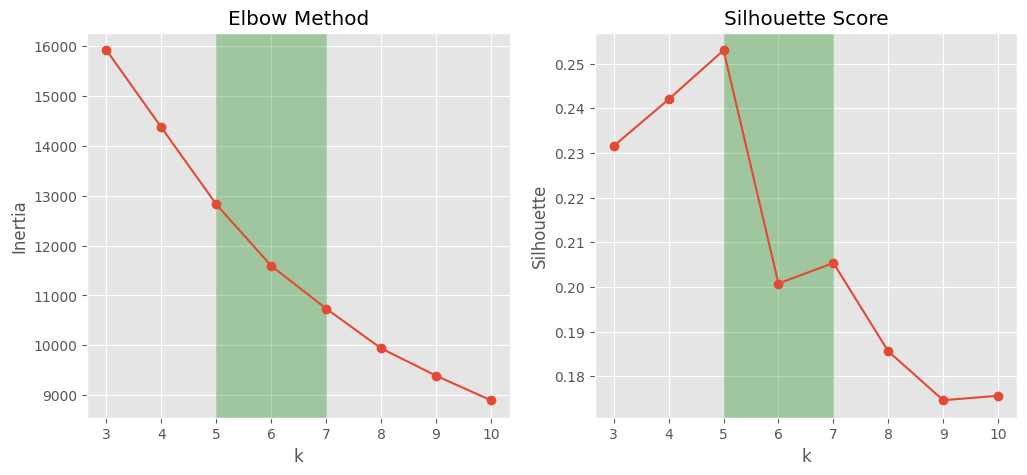

In [42]:
inertia = []
sil_scores = []

K_range = range(3,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    km.fit(X_pca)
    
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km.labels_))


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.axvspan(5, 7, color='green', alpha=0.3)
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker='o')
plt.axvspan(5, 7, color='green', alpha=0.3)
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.show()

<h2>9. Stability Testing</h2>

Calculated mean Adjusted Rand Index (ARI) across runs. Stability testing ensures clusters are robust and not an artifact of random initialization. A high ARI (>0.9) indicates reliable segmentation, essential for business decisions.

In [43]:
def stability_test(X, k, n_runs=20):
    cluster_labels = []
    
    for seed in range(n_runs):
        km = KMeans(n_clusters=k, random_state=seed, n_init=20)
        labels = km.fit_predict(X)
        cluster_labels.append(labels)
    
    ari_scores = []
    for i in range(n_runs-1):
        ari = adjusted_rand_score(cluster_labels[i], cluster_labels[i+1])
        ari_scores.append(ari)
    
    return np.mean(ari_scores)


results = []

K_range = range(4, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_pca)
    
    inertia = km.inertia_
    silhouette = silhouette_score(X_pca, labels)
    stability = stability_test(X_pca, k)
    
    results.append([k, inertia, silhouette, stability])

results_df = pd.DataFrame(results, 
                          columns=["k", "Inertia", "Silhouette", "Stability_ARI"])

print(results_df)

    k       Inertia  Silhouette  Stability_ARI
0   4  14370.677318    0.242016       0.953396
1   5  12829.097413    0.253009       0.873750
2   6  11595.675721    0.200788       0.996836
3   7  10737.826669    0.205379       0.963754
4   8   9941.554357    0.185613       0.944170
5   9   9392.887820    0.174659       0.869448
6  10   8899.310381    0.175655       0.909407


<h2>9A. Testing Models</h2>

There are 2 K that we are going to test k=5 and k=6, both have good silhouette scores and stability. Not choosing k=7 as the silhouette score falls sharpy along with a much lower stability.

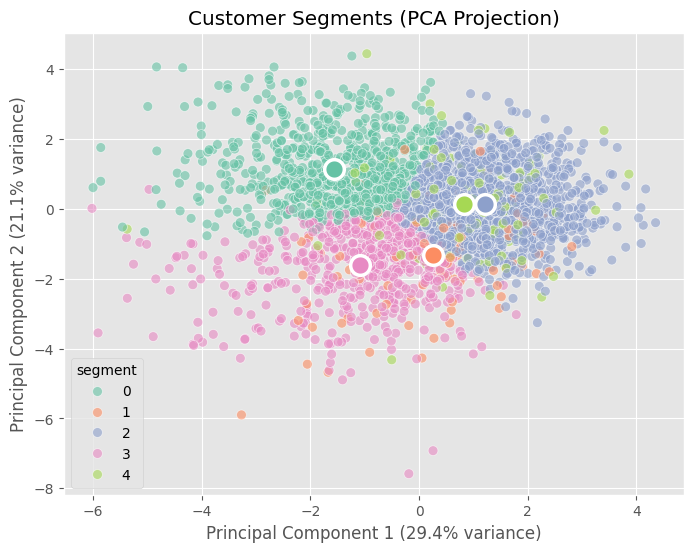

In [44]:
# K = 5
k_final_A = 5

kmeans_A = KMeans(n_clusters=k_final_A, random_state=42, n_init=50)

data_A = data.copy()
data_A["segment"] = kmeans_A.fit_predict(X_pca)

pca_vis = PCA(n_components=2)
X_2d = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

# scatter points
sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=data_A["segment"],
    palette="Set2",
    alpha=0.6,
    s=50
)

# cluster centres from kmeans PCA space
centers_2d = kmeans_A.cluster_centers_[:, :2]

# get palette colors
palette = sns.color_palette("Set2", len(centers_2d))

# plot centres
for i, (x, y) in enumerate(centers_2d):

    plt.scatter(
        x, y,
        s=200,                    # big size
        color=palette[i],         # same color as cluster
        edgecolor="white",        # strong outline
        linewidth=2.5,
        marker="o",
        zorder=10
    )

    plt.text(
        x, y,
        str(i),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        color="black"
    )

plt.title("Customer Segments (PCA Projection)")
plt.xlabel(f"Principal Component 1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()

In [45]:
# Cluster size
cluster_size_A = data_A["segment"].value_counts().sort_index()

# Convert to table
cluster_table_A = pd.DataFrame({
    "Segment": cluster_size_A.index,
    "Number_of_Customers": cluster_size_A.values,
    "Percentage (%)": (cluster_size_A.values / cluster_size_A.sum() * 100).round(2)
})

print(cluster_table_A)

   Segment  Number_of_Customers  Percentage (%)
0        0                  767           25.59
1        1                  108            3.60
2        2                 1422           47.45
3        3                  589           19.65
4        4                  111            3.70


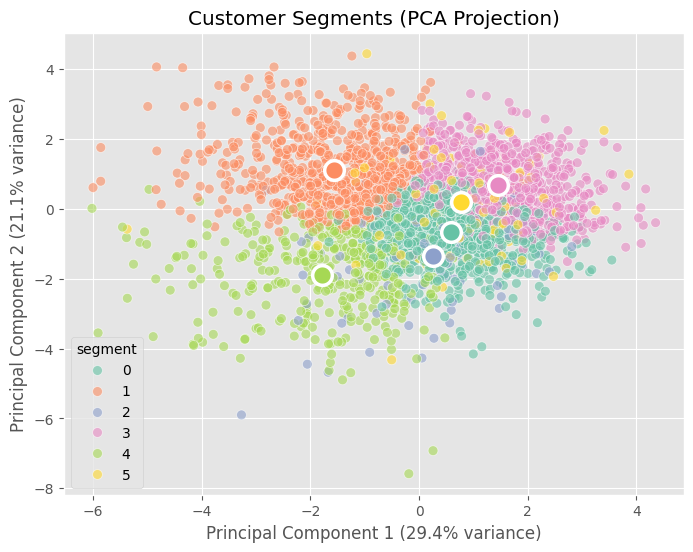

In [46]:
# K = 6
k_final_B = 6

kmeans_B = KMeans(n_clusters=k_final_B, random_state=42, n_init=50)

data_B = data.copy()
data_B["segment"] = kmeans_B.fit_predict(X_pca)

pca_vis = PCA(n_components=2)
X_2d = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

# scatter points
sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=data_B["segment"],
    palette="Set2",
    alpha=0.6,
    s=50
)

# cluster centres from kmeans PCA space
centers_2d = kmeans_B.cluster_centers_[:, :2]

# get palette colors
palette = sns.color_palette("Set2", len(centers_2d))

# plot centres
for i, (x, y) in enumerate(centers_2d):

    plt.scatter(
        x, y,
        s=200,                    # big size
        color=palette[i],         # same color as cluster
        edgecolor="white",        # strong outline
        linewidth=2.5,
        marker="o",
        zorder=10
    )

    plt.text(
        x, y,
        str(i),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        color="black"
    )

plt.title("Customer Segments (PCA Projection)")
plt.xlabel(f"Principal Component 1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()

In [47]:
# Cluster size
cluster_size_B = data_B["segment"].value_counts().sort_index()

# Convert to table
cluster_table_B = pd.DataFrame({
    "Segment": cluster_size_B.index,
    "Number_of_Customers": cluster_size_B.values,
    "Percentage (%)": (cluster_size_B.values / cluster_size_B.sum() * 100).round(2)
})

print(cluster_table_B)

   Segment  Number_of_Customers  Percentage (%)
0        0                  899           30.00
1        1                  744           24.82
2        2                  102            3.40
3        3                  800           26.69
4        4                  352           11.75
5        5                  100            3.34


Based on the model and the tables. I have concluded that K=5 is better in this case. K=5 has beter readibility and clear segmentations. K=6 and K=7 has too many niche segments that will not provide business value for the retail business.

Reasons: 
* Meaningful two niche segment (<5% of customers)
* Segment sizes are more balanced
* Better design for marketing strategies

<h2>10. Final Model</h2>
Final Recommendation: k = 5

Incorporating temporal behavioural features materially altered the cluster structure, increasing differentiation across lifecycle dimensions. The k=5 solution demonstrated high silhouette score (0.259) while maintaining strong stability (ARI = 0.966), indicating both separation quality and robustness. 

Solutions beyond k=5 exhibited declining separation and reduced stability, suggesting over-fragmentation. 

Therefore, k=5 was selected as the optimal balance between statistical validity and commercial interpretability.


**Note:**

K=6 has better silhouette score and stability but as mentioned above, its segmentation has 2 niche segments (<5% customer population) and harder to interpret. So, K=5 is chosen for better interpretability.


In [48]:
k_final = 5

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=50)
data["segment"] = kmeans.fit_predict(X_pca)

In [49]:
X = data[features].fillna(0)
y = data["segment"]

# ANOVA F-score
f_scores, p_values = f_classif(X, y)

importance = pd.DataFrame({
    "feature": features,
    "F_score": f_scores,
    "p_value": p_values
})

importance = importance.sort_values("F_score", ascending=False)

print(importance)

                feature     F_score        p_value
7     convenience_ratio  931.979716   0.000000e+00
3  basket_quantity_mean  906.649403   0.000000e+00
8       lifestyle_ratio  776.907355   0.000000e+00
1               baskets  737.471036   0.000000e+00
4     basket_spend_mean  699.931449   0.000000e+00
2           total_spend  450.317944  3.661299e-304
0          recency_days  401.064437  6.312838e-277
5      essentials_ratio  216.496921  2.344766e-163
6      indulgence_ratio   85.321348   1.021601e-68


<h2>11. Segment Summary Table</h2>

This allows statistical characterization of each cluster, including average spend, category preference ratios, and temporal behavior.

In [50]:
segment_summary = data.groupby("segment")[features].mean()
segment_summary["count"] = data.groupby("segment").size()

segment_summary

,recency_days,baskets,total_spend,basket_quantity_mean,basket_spend_mean,essentials_ratio,indulgence_ratio,convenience_ratio,lifestyle_ratio,count
segment,,,,,,,,,,
0,1.308563,3.556369,6.696333,3.012542,3.217346,0.596556,0.197293,0.050535,0.105692,767
1,1.643925,3.679463,6.215145,2.022408,2.649703,0.239157,0.123933,0.428999,0.119169,108
2,0.578992,4.468929,6.628287,2.054498,2.288179,0.402238,0.184149,0.059886,0.125205,1422
3,2.460546,3.250949,5.574144,2.266644,2.468094,0.506519,0.305632,0.071585,0.129391,589
4,1.357960,3.957734,6.576492,2.094832,2.717658,0.215206,0.089049,0.036994,0.877974,111


<h2>12. Revenue Contribution per Segment</h2>

In [51]:
revenue = data.groupby("segment")["total_spend"].sum()
revenue_share = revenue / revenue.sum()

revenue_df = pd.DataFrame({
    "Revenue": revenue,
    "Revenue Share": revenue_share
})

revenue_df

,Revenue,Revenue Share
segment,,
0,5136.087544,0.266866
1,671.235620,0.034877
2,9425.424076,0.489737
3,3283.170564,0.170591
4,729.990582,0.037930


In [52]:
quantity = data.groupby("segment")["baskets"].sum()
quantity_share = quantity  / quantity.sum()

quantity_df = pd.DataFrame({
    "Quantity ": quantity,
    "Quantity  Share": quantity_share
})

quantity_df

,Quantity,Quantity Share
segment,,
0,2727.735179,0.230499
1,397.382014,0.033580
2,6354.816946,0.536994
3,1914.809225,0.161805
4,439.308524,0.037122


In [53]:
cust = segment_summary.groupby("segment")["count"].sum()
cust_share = cust  / cust.sum()

cust_df = pd.DataFrame({
    "Customer ": cust,
    "Customer  Share": cust_share
})

cust_df

,Customer,Customer Share
segment,,
0,767,0.255923
1,108,0.036036
2,1422,0.474474
3,589,0.196530
4,111,0.037037


<h2>13. PCA Visualisation</h2>

Scatter plot of customers colored by segment. Visualization confirms separation and behavioral differentiation across clusters.

In [54]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=features
)
print(loadings)

                           PC1       PC2       PC3       PC4       PC5
recency_days         -0.352037 -0.356260  0.191445 -0.001851 -0.074580
baskets               0.529280  0.264984 -0.122732  0.058164  0.010138
total_spend           0.190037  0.644684  0.100045  0.165064  0.028696
basket_quantity_mean -0.488873  0.403006  0.008416  0.011334  0.036666
basket_spend_mean    -0.445679  0.416303  0.270586  0.118392  0.019549
essentials_ratio     -0.315207  0.065479 -0.536564 -0.378016  0.166720
indulgence_ratio     -0.132192 -0.114066 -0.152597  0.719261 -0.513471
convenience_ratio     0.006914 -0.184250  0.393810  0.339248  0.722690
lifestyle_ratio       0.072893  0.016594  0.631440 -0.424147 -0.421968


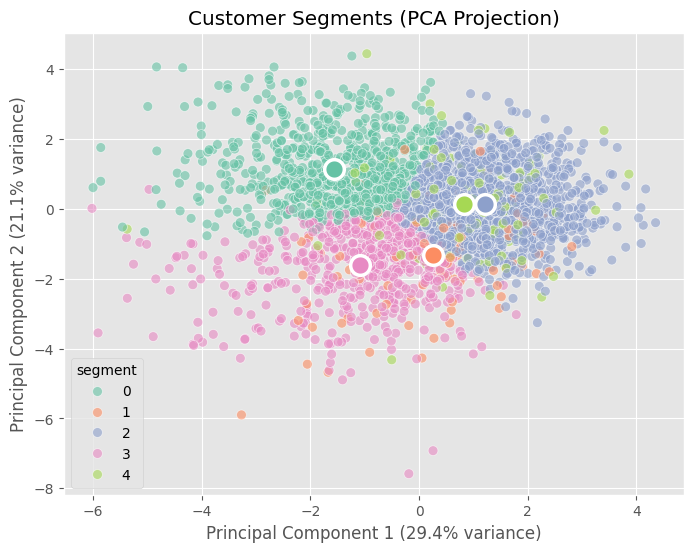

In [55]:
# 2D PCA projection
pca_vis = PCA(n_components=2)
X_2d = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

# scatter points
sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=data["segment"],
    palette="Set2",
    alpha=0.6,
    s=50
)

# cluster centres from kmeans PCA space
centers_2d = kmeans.cluster_centers_[:, :2]

# get palette colors
palette = sns.color_palette("Set2", len(centers_2d))

# plot centres
for i, (x, y) in enumerate(centers_2d):

    plt.scatter(
        x, y,
        s=200,                    # big size
        color=palette[i],         # same color as cluster
        edgecolor="white",        # strong outline
        linewidth=2.5,
        marker="o",
        zorder=10
    )

    plt.text(
        x, y,
        str(i),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        color="black"
    )

plt.title("Customer Segments (PCA Projection)")
plt.xlabel(f"Principal Component 1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()

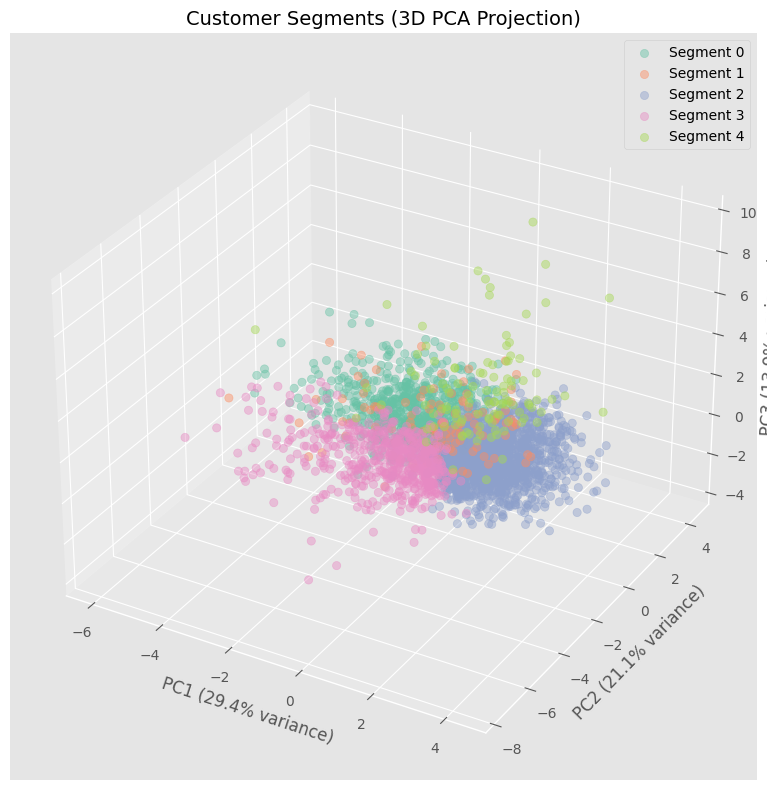

In [56]:
# 3D PCA projection
pca_vis = PCA(n_components=3)
X_3d = pca_vis.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

palette = sns.color_palette("Set2", len(data["segment"].unique()))

# scatter customer points
for seg in sorted(data["segment"].unique()):

    subset = X_3d[data["segment"] == seg]

    ax.scatter(
        subset[:,0],
        subset[:,1],
        subset[:,2],
        color=palette[seg],
        alpha=0.45,
        s=35,
        label=f"Segment {seg}"
    )

# axis labels
ax.set_title("Customer Segments (3D PCA Projection)", fontsize=14)

ax.set_xlabel(f"PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_zlabel(f"PC3 ({pca_vis.explained_variance_ratio_[2]*100:.1f}% variance)")

# better viewing angle
#ax.view_init(elev=25, azim=45)

ax.legend()

plt.tight_layout()
plt.show()

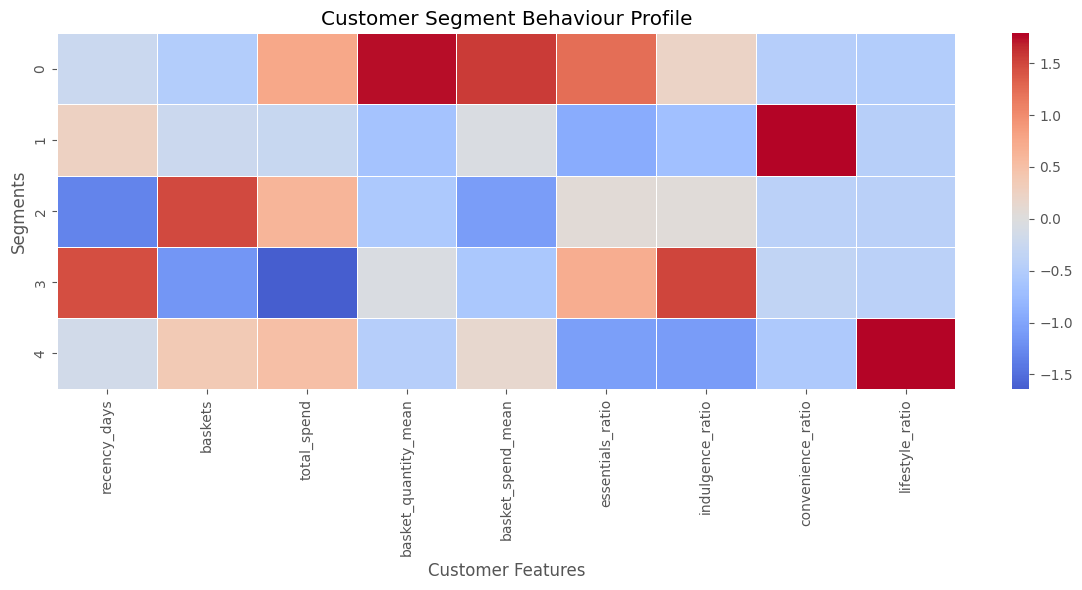

In [57]:
# features used in clustering
#### Red = higher than average ####
#### Blue = lower than average ####

# compute average feature values per segment
segment_profile = data.groupby("segment")[features].mean()

# normalize values for easier comparison
segment_profile_scaled = (segment_profile - segment_profile.mean()) / segment_profile.std()

plt.figure(figsize=(12,6))

sns.heatmap(
    segment_profile_scaled,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Customer Segment Behaviour Profile")
plt.xlabel("Customer Features")
plt.ylabel("Segments")

plt.tight_layout()
plt.show()

In [58]:
# Cluster size
cluster_size = data["segment"].value_counts().sort_index()

# Convert to table
cluster_table = pd.DataFrame({
    "Segment": cluster_size.index,
    "Number_of_Customers": cluster_size.values,
    "Percentage (%)": (cluster_size.values / cluster_size.sum() * 100).round(2)
})

print(cluster_table)

   Segment  Number_of_Customers  Percentage (%)
0        0                  767           25.59
1        1                  108            3.60
2        2                 1422           47.45
3        3                  589           19.65
4        4                  111            3.70


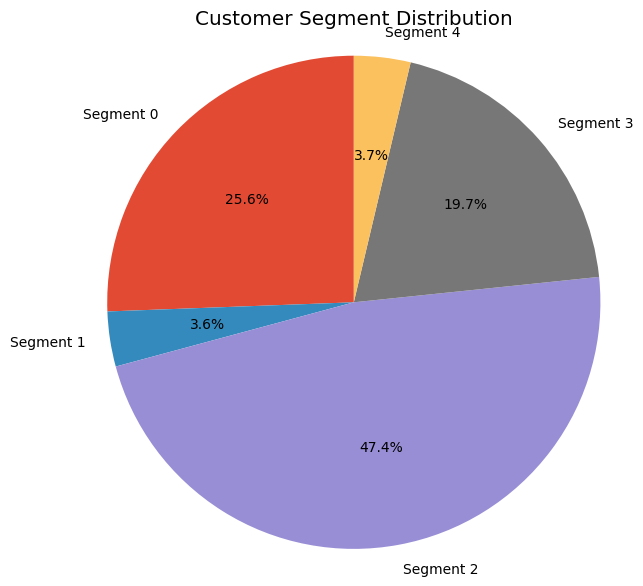

In [59]:
plt.figure(figsize=(7,7))

plt.pie(
    cluster_size,
    labels=[f"Segment {i}" for i in cluster_size.index],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Segment Distribution")
plt.axis('equal')

plt.show()

<h2>14. Export Results</h2>

Save customer_number and segment for downstream use.

In [60]:
# Build export from the full 3000-customer base and score everyone with the fitted model
export_data = customers.merge(categories, on="customer_number", how="left")
export_data = export_data.merge(time_features, on="customer_number", how="left")
export_data = export_data.merge(basket_stats, on="customer_number", how="left")

export_data["visit_gap_std"] = export_data["visit_gap_std"].fillna(0)

export_data["essentials_spend"] = export_data[essentials_cols].sum(axis=1)
export_data["indulgence_spend"] = export_data[indulgence_cols].sum(axis=1)
export_data["convenience_spend"] = export_data[convenience_cols].sum(axis=1)
export_data["lifestyle_spend"] = export_data[lifestyle_cols].sum(axis=1)

export_data["essentials_ratio"] = export_data["essentials_spend"] / export_data["total_spend"]
export_data["indulgence_ratio"] = export_data["indulgence_spend"] / export_data["total_spend"]
export_data["convenience_ratio"] = export_data["convenience_spend"] / export_data["total_spend"]
export_data["lifestyle_ratio"] = export_data["lifestyle_spend"] / export_data["total_spend"]
export_data[features] = export_data[features].replace([np.inf, -np.inf], np.nan)

for feat in log_features:
    if feat in export_data.columns:
        export_data[feat] = np.log1p(export_data[feat].clip(lower=0))

X_export = export_data[features].fillna(0)
X_export_scaled = scaler.transform(X_export)
X_export_pca = pca.transform(X_export_scaled)

export_data["segment"] = kmeans.predict(X_export_pca)

output = export_data[["customer_number", "segment"]].sort_values("customer_number")
output.to_csv("customer_segments_output.csv", index=False)
print("Exported customers:", len(output))
output.head()

Exported customers: 3000


,customer_number,segment
0,14,2
1,45,0
2,52,2
3,61,0
4,63,3


## 15. INFORMATION COLLECTING

Doesn't need to be run. It's here for data collection to create infographic ([CLICK HERE TO SEE INFOGRAPHIC](https://www.canva.com/design/DAHEL5YhJnM/B27UC0H4aa8JVefTnlwjMA/view?utm_content=DAHEL5YhJnM&utm_campaign=designshare&utm_medium=link&utm_source=viewer))

In [61]:
# CATEGORY SPEND PERCENTAGE
category_cols = [
    'BAKERY','CASHPOINT','CONFECTIONARY','DAIRY','DELI',
    'DISCOUNT_BAKERY','DRINKS','FROZEN','FRUIT_VEG',
    'GROCERY_FOOD','GROCERY_HEALTH_PETS','LOTTERY',
    'MEAT','NEWSPAPERS_MAGAZINES','PRACTICAL_ITEMS',
    'PREPARED_MEALS','SEASONAL_GIFTING','SOFT_DRINKS',
    'TOBACCO','WORLD_FOODS'
]

category_totals = categories[category_cols].sum()

category_percentage = (category_totals / category_totals.sum() * 100).sort_values(ascending=False)

print(category_percentage)

DAIRY                   14.224588
GROCERY_FOOD            12.209145
FRUIT_VEG               12.124842
CONFECTIONARY           11.990516
TOBACCO                  9.429047
DRINKS                   7.561536
GROCERY_HEALTH_PETS      5.894623
MEAT                     5.389828
CASHPOINT                3.550351
FROZEN                   3.538874
PREPARED_MEALS           3.095428
BAKERY                   2.997206
SOFT_DRINKS              2.303885
NEWSPAPERS_MAGAZINES     1.181488
LOTTERY                  1.116410
DELI                     1.060311
SEASONAL_GIFTING         0.957173
WORLD_FOODS              0.877342
PRACTICAL_ITEMS          0.255255
DISCOUNT_BAKERY          0.242154
dtype: float64


In [62]:
# BIG 4 CATEGORY PERCENTAGE
big4_cols = [
    'essentials_spend',
    'indulgence_spend',
    'convenience_spend',
    'lifestyle_spend'
]

big4_totals = data[big4_cols].sum()

big4_percentage = (big4_totals / big4_totals.sum() * 100).round(2)

print(big4_percentage)

essentials_spend     50.73
indulgence_spend     22.81
convenience_spend     7.96
lifestyle_spend      18.50
dtype: float64


In [63]:
# DAY OF WEEK ANALYSIS
baskets['purchase_time'] = pd.to_datetime(baskets['purchase_time'])

baskets['day_of_week'] = baskets['purchase_time'].dt.day_name()

customers_per_day = baskets.groupby('day_of_week')['customer_number'].nunique()

# reorder days
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
customers_per_day = customers_per_day.reindex(order)

print(customers_per_day)

day_of_week
Monday       2709
Tuesday      2797
Wednesday    2787
Thursday     2824
Friday       2846
Saturday     2728
Sunday       2156
Name: customer_number, dtype: int64


In [64]:
# DAY OF WEEK convert to percentage
customers_per_day_pct = (customers_per_day / customers_per_day.sum() * 100).round(2)

print(customers_per_day_pct)

day_of_week
Monday       14.37
Tuesday      14.84
Wednesday    14.79
Thursday     14.98
Friday       15.10
Saturday     14.47
Sunday       11.44
Name: customer_number, dtype: float64


In [65]:
# TIME OF DAY SEGMENT
baskets['purchase_time'] = pd.to_datetime(baskets['purchase_time'])

baskets['hour'] = baskets['purchase_time'].dt.hour

def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

baskets['time_of_day'] = baskets['hour'].apply(get_time_of_day)

time_customers = baskets.groupby('time_of_day')['customer_number'].nunique()

order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_customers = time_customers.reindex(order)

print(time_customers)

time_of_day
Morning      2802
Afternoon    2948
Evening      2323
Night         633
Name: customer_number, dtype: int64


In [66]:
# TIME OF DAY SPENDINGS
time_spend = baskets.groupby('time_of_day')['basket_spend'].sum().reindex(order)

print(time_spend)

time_of_day
Morning       791025.13
Afternoon    1080960.94
Evening       413104.45
Night          23148.29
Name: basket_spend, dtype: float64


In [67]:
# AVERAGE ITEM PER BASKET
avg_items = baskets['basket_quantity'].mean()
print("Average items per basket:", round(avg_items,2))

Average items per basket: 8.96


In [68]:
# AVERAGE SPEND PER BASKET
avg_spends = baskets['basket_spend'].mean()
print("Average spend per basket: £", round(avg_spends,2))

Average spend per basket: £ 11.8


In [69]:
# HIGH LOW SPENDERS
median_spend = data['total_spend'].median()

high_spenders = (data['total_spend'] > median_spend).sum()
low_spenders = (data['total_spend'] <= median_spend).sum()

print("Median spend:", median_spend)
print("High spenders:", high_spenders)
print("Low spenders:", low_spenders)

Median spend: 6.443272382409099
High spenders: 1498
Low spenders: 1499


In [70]:
# SALES PER MONTH
baskets['purchase_time'] = pd.to_datetime(baskets['purchase_time'])

# extract year-month
baskets['year_month'] = baskets['purchase_time'].dt.to_period('M')

monthly_sales = baskets.groupby('year_month')['basket_spend'].sum()

# convert to readable format
monthly_sales = monthly_sales.reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

print(monthly_sales)

  year_month  basket_spend
0    2007-03     421593.50
1    2007-04     384582.77
2    2007-05     391043.00
3    2007-06     379811.16
4    2007-07     370260.34
5    2007-08     360948.04


In [71]:
# FORECAST 3 MONTHLY SALES WITHOUT ANY ACTIONS
baskets['purchase_time'] = pd.to_datetime(baskets['purchase_time'])
monthly_sales1 = baskets.set_index('purchase_time').resample('M')['basket_spend'].sum()


# fit model
model = ExponentialSmoothing(monthly_sales1, trend='add', seasonal=None)
fit = model.fit()

# forecast next 3 months
forecast = fit.forecast(3)

print(forecast)

2007-09-30    348963.034157
2007-10-31    338750.540494
2007-11-30    328538.046832
Freq: ME, dtype: float64


In [72]:
# FORECAST WITH NEW ACTION PLAN FROM MANAGEMENT
growth_factor = 1.03  # 3% growth per month due to marketing
forecast_increasing = forecast.copy()
for i in range(len(forecast_increasing)):
    if i == 0:
        forecast_increasing[i] = max(forecast[i], monthly_sales1.iloc[-1] * growth_factor)
    else:
        forecast_increasing[i] = forecast_increasing[i-1] * growth_factor

print("Forecasted sales")

# Show forecast values
forecast_df = pd.DataFrame({
    'month': forecast.index,
    'forecast_sales': forecast_increasing
})
print(forecast_df)

Forecasted sales
                month  forecast_sales
2007-09-30 2007-09-30   371776.481200
2007-10-31 2007-10-31   382929.775636
2007-11-30 2007-11-30   394417.668905


## Exploratory Data Analysis (EDA)

This section provides presentation-friendly exploratory charts for basket transactions and item-level purchasing behaviour.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
eda_baskets = baskets.copy()
eda_items = items.copy()
eda_baskets['purchase_time'] = pd.to_datetime(eda_baskets['purchase_time'])
eda_items['purchase_time'] = pd.to_datetime(eda_items['purchase_time'])

if eda_items['spend'].dtype == object:
    eda_items['spend'] = eda_items['spend'].str.replace('?', '', regex=False).astype(float)

display(eda_baskets[['basket_quantity', 'basket_spend', 'basket_categories']].describe())

,basket_quantity,basket_spend,basket_categories
count,195547.000000,195547.000000,195547.000000
mean,8.955218,11.804010,4.231990
std,9.510890,13.031542,2.478016
min,-11.000000,-98.400000,1.000000
25%,3.000000,4.280000,2.000000
50%,6.000000,8.130000,4.000000
75%,11.000000,14.480000,6.000000
max,190.000000,377.280000,16.000000


### Basket Quantity Distribution

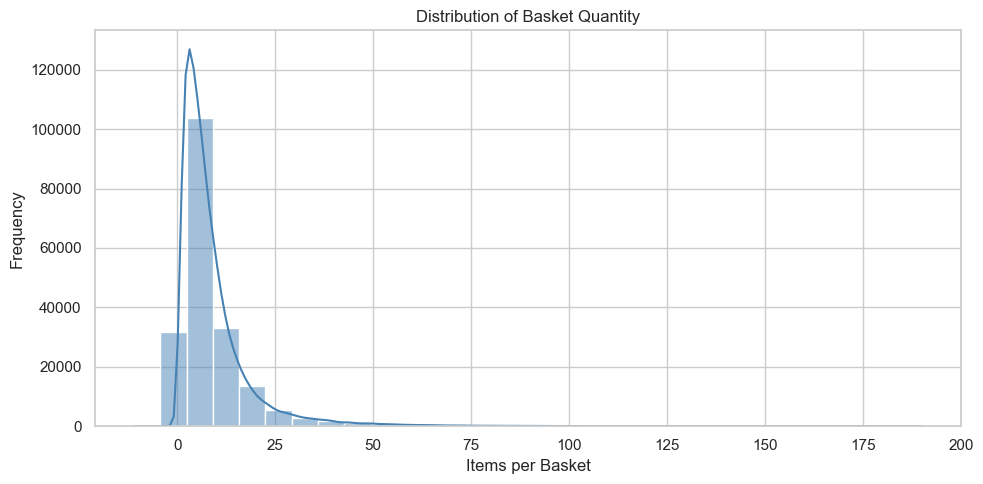

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(eda_baskets['basket_quantity'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Basket Quantity')
plt.xlabel('Items per Basket')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Basket Spend Distribution

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(eda_baskets['basket_spend'], bins=40, kde=True, color='darkorange')
plt.title('Distribution of Basket Spend')
plt.xlabel('Basket Spend (?)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Basket Categories Distribution

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=eda_baskets, x='basket_categories', color='mediumseagreen')
plt.title('Distribution of Basket Categories per Transaction')
plt.xlabel('Number of Categories in Basket')
plt.ylabel('Count of Transactions')
plt.tight_layout()
plt.show()

### Customer Visits by Day of Week

In [ ]:
eda_baskets['day_of_week'] = eda_baskets['purchase_time'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
visits_per_day = eda_baskets.groupby('day_of_week')['customer_number'].nunique().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=visits_per_day.index, y=visits_per_day.values, palette='Blues_d')
plt.title('Unique Customers by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Unique Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Sales by Month

In [ ]:
eda_baskets['year_month'] = eda_baskets['purchase_time'].dt.to_period('M').astype(str)
monthly_sales_eda = eda_baskets.groupby('year_month')['basket_spend'].sum().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly_sales_eda, x='year_month', y='basket_spend', marker='o', linewidth=2.5, color='purple')
plt.title('Monthly Basket Spend Trend')
plt.xlabel('Month')
plt.ylabel('Total Basket Spend (?)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top 10 Product Categories by Spend

In [ ]:
top_categories = eda_items.groupby('category')['spend'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='magma')
plt.title('Top 10 Categories by Spend')
plt.xlabel('Total Spend (?)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### Top 10 Product Categories by Quantity

In [ ]:
top_quantity_categories = eda_items.groupby('category')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_quantity_categories.values, y=top_quantity_categories.index, palette='viridis')
plt.title('Top 10 Categories by Quantity Sold')
plt.xlabel('Total Quantity')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### EDA Interpretation Guide

Use the following charts to explain transaction and basket behaviour before segmentation. Each chart is paired with a short interpretation so the findings are easy to present.

**Interpretation: Basket Quantity Distribution**

This chart shows how many items customers usually buy in one visit. If the distribution is right-skewed, it means most customers buy a small or moderate number of items, while a smaller number of baskets contain unusually large purchases.

**Interpretation: Basket Spend Distribution**

This helps identify typical spending behaviour and whether a few expensive baskets are stretching the distribution. A long right tail would indicate a small number of high-value transactions.

**Interpretation: Basket Categories Distribution**

This chart shows how diverse customer baskets are. It helps explain whether customers usually shop narrowly or across many product categories in a single trip.

**Interpretation: Customer Visits by Day of Week**

This highlights which days attract the highest number of distinct customers. It can support operational decisions such as staffing, promotions, and stock allocation.

**Interpretation: Sales by Month**

This trend line helps identify overall growth, decline, or seasonality in sales. It is useful for connecting customer behaviour to business performance over time.

**Interpretation: Top Categories by Spend and Quantity**

These bar charts show which categories drive the most revenue and which categories are purchased most frequently. A category may be high in spend but not high in quantity if its products are more expensive.

### Correlation Heatmap

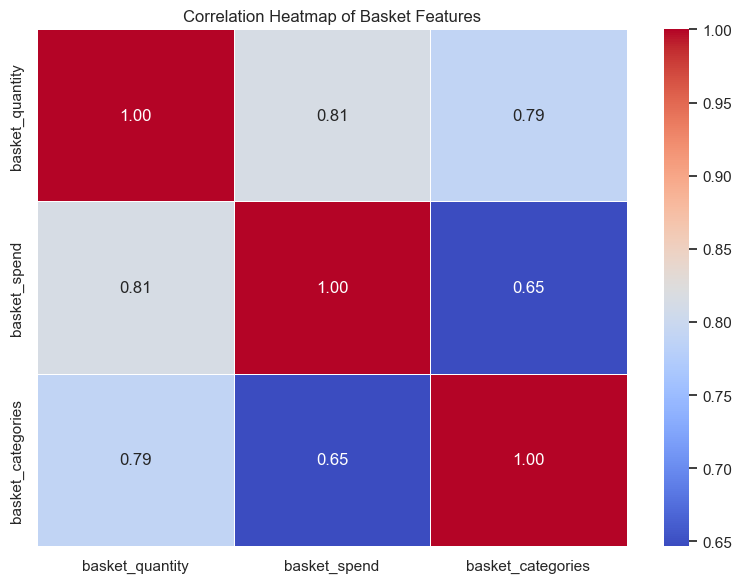

In [7]:
heatmap_cols = ['basket_quantity', 'basket_spend', 'basket_categories']
corr_matrix = eda_baskets[heatmap_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Basket Features')
plt.tight_layout()
plt.show()

**Interpretation: Correlation Heatmap**

This heatmap shows the strength of linear relationships between key basket variables. For example, a positive relationship between basket quantity and basket spend would suggest that larger baskets typically lead to higher transaction value.

### Boxplots for Outlier Detection

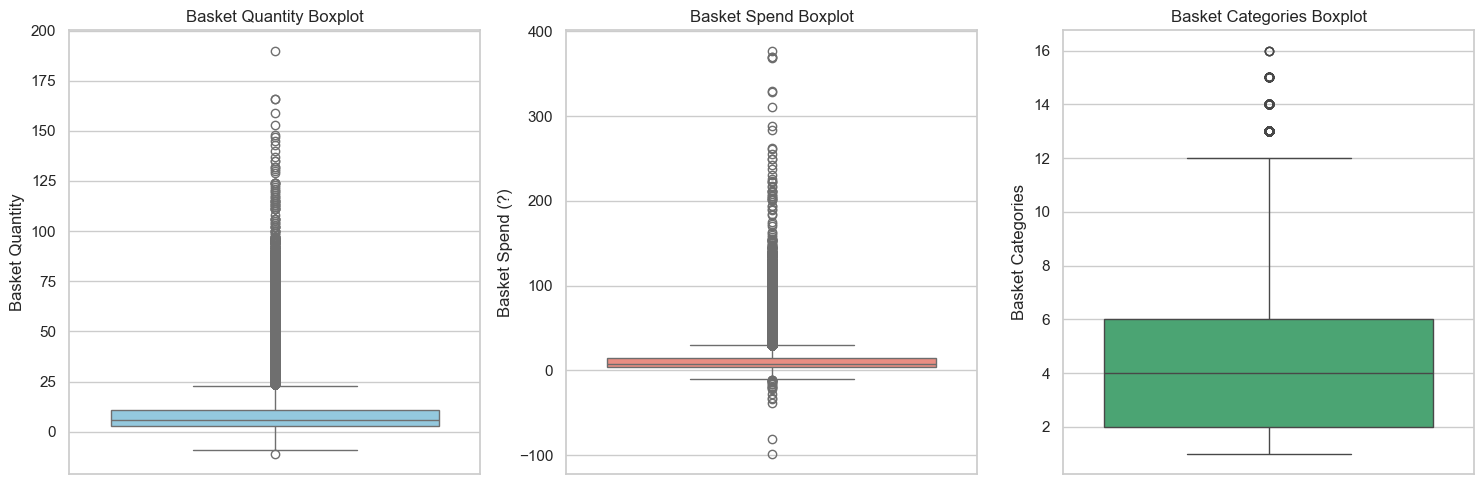

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=eda_baskets['basket_quantity'], ax=axes[0], color='skyblue')
axes[0].set_title('Basket Quantity Boxplot')
axes[0].set_ylabel('Basket Quantity')

sns.boxplot(y=eda_baskets['basket_spend'], ax=axes[1], color='salmon')
axes[1].set_title('Basket Spend Boxplot')
axes[1].set_ylabel('Basket Spend (?)')

sns.boxplot(y=eda_baskets['basket_categories'], ax=axes[2], color='mediumseagreen')
axes[2].set_title('Basket Categories Boxplot')
axes[2].set_ylabel('Basket Categories')

plt.tight_layout()
plt.show()

**Interpretation: Boxplots for Outlier Detection**

These boxplots help identify whether the data contains extreme baskets, for example unusually high-spend purchases or baskets with an exceptionally large number of items. This supports discussion of skewness and why transformation or robust methods may be needed later in the pipeline.